In [6]:
import ase.io
import plumed
import numpy as np
import subprocess

In [9]:
import os
os.chdir("..")

import utils.figures as figures

os.chdir("SN2")

## Load data

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/gguiard@iit.local/plumed-opes-libtorch-python/lib/libplumedKernel.so" +++


mkdir: cannot create directory ‘TEST_TRAJ’: File exists


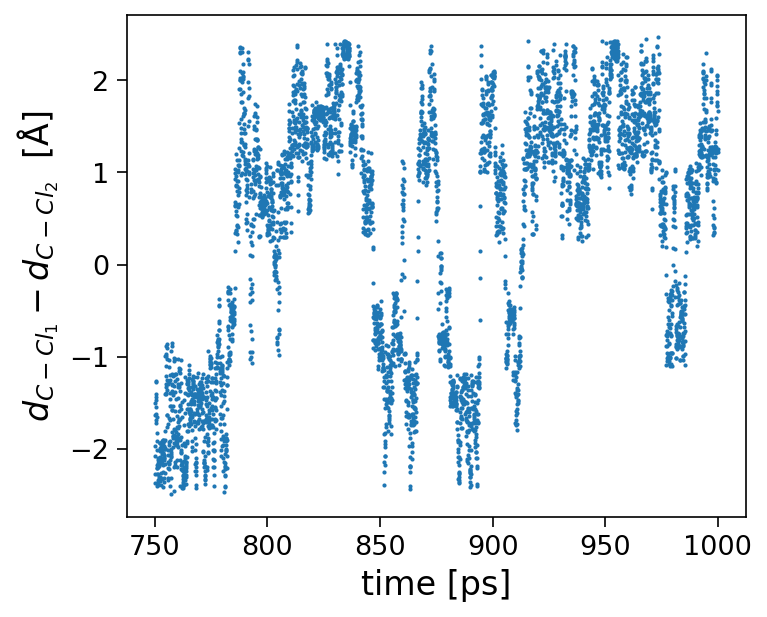

In [14]:
test_traj = ase.io.read("OPES/traj_comp.traj", "150001::10") # 200001
data = plumed.read_as_pandas("OPES/COLVAR").iloc[::10][150001::10]

figures.chemiscope(
    test_traj,
    data["time"].to_numpy().T,
    data["d1"].to_numpy().T,
    data["d2"].to_numpy().T,
    save_directory="TEST_TRAJ",
)

fig = figures.trj(
    time=data["time"].to_numpy(),
    cv=data["dd"].to_numpy().T,
    label=r"$d_{C-Cl_1} - d_{C-Cl_2}$  [Å]",
)
fig.savefig("TEST_TRAJ/trj_dd.svg")

!mkdir TEST_TRAJ
ase.io.write("TEST_TRAJ/traj.xyz", test_traj)
data.to_csv("TEST_TRAJ/COLVAR", index=False)

In [16]:
labels = {
    "q_Hirshfeld": r"$q_{Cl_1} - q_{Cl_2}\ (Hirshfeld)\ [e]$",
    "sigma_MBIS": r"$\sigma_{Cl_1} - \sigma_{Cl_2}\ (MBIS)$",
    "b_Mayer": r"$b_{Cl_1} - b_{Cl_2}\ (Mayer)$",
    "q_AO_Loewdin": r"$q_{Cl_1} - q_{Cl_2}\ (Loewdin\ p)\ [e]$",
    "p_MOAO_Loewdin": r"$q_{Cl_1} - q_{Cl_2}\ (Loewdin\ HOMO\ p)\ [e]$",
}

labels_derivative = {
    "q_Hirshfeld": r"$max(|\partial(q_{Cl_1} - q_{Cl_2})|)\ (Hirshfeld)\ [e]$",
    "sigma_MBIS": r"$max(|\partial(\sigma_{Cl_1} - \sigma_{Cl_2})|)\ (MBIS)$",
    "b_Mayer": r"$max(|\partial(b_{Cl_1} - b_{Cl_2})|)\ (Mayer)$",
    "q_AO_Loewdin": r"$max(|\partial(q_{Cl_1} - q_{Cl_2})|)\ (Loewdin\ p)\ [e]$",
    "p_MOAO_Loewdin": r"$max(|\partial(q_{Cl_1} - q_{Cl_2})|)\ (Loewdin\ HOMO\ p)\ [e]$",
}

## Calculate value and gradient

In [7]:
for key in labels:
    subprocess.run(
        f"""
        cd TEST_TRAJ/{key}; \
        rm bck.* CHEMCV*; \
        PLUMED_SOURCE=/home/gguiard@iit.local/plumed-2.10.0/sourceme.sh; \
        plumed driver --plumed plumed-chemcv.dat --ixyz ../traj.xyz --box 201.78283,201.543977,203.655951 --length-units A;
        """,
        shell = True
    )

rm: cannot remove 'bck.*': No such file or directory


./../PytorchModelGNN.2.10.0.so is already up to date
PLUMED: PLUMED is starting
PLUMED: Version: 2.10.0 (git: Unknown) compiled on Mar 31 2026 at 15:12:10
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /home/gguiard@iit.local/plumed-opes-libtorch-python/lib/plumed
PLUMED: LibraryPath: /home/gguiard@iit.local/plumed-opes-libtorch-python/lib/libplumedKernel.so
PLUMED: For installed feature, see /home/gguiard@iit.local/plumed-opes-libtorch-python/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 6
PLUMED: File suffix: 
PLUMED: FILE: plumed-chemcv.dat
PLUMED: Action UNITS
PLUMED:   with label @0
PLUMED:   length: A = 0.1 nm
PLUMED:   energy: kj/mol
PLUMED:   time: ps
PLUMED:   charge: e
PLUMED:   mass: amu
PLUMED:   using 

rm: cannot remove 'bck.*': No such file or directory
rm: cannot remove 'CHEMCV*': No such file or directory


./../PytorchModelGNN.2.10.0.so is already up to date
PLUMED: PLUMED is starting
PLUMED: Version: 2.10.0 (git: Unknown) compiled on Mar 31 2026 at 15:12:10
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /home/gguiard@iit.local/plumed-opes-libtorch-python/lib/plumed
PLUMED: LibraryPath: /home/gguiard@iit.local/plumed-opes-libtorch-python/lib/libplumedKernel.so
PLUMED: For installed feature, see /home/gguiard@iit.local/plumed-opes-libtorch-python/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 6
PLUMED: File suffix: 
PLUMED: FILE: plumed-chemcv.dat
PLUMED: Action UNITS
PLUMED:   with label @0
PLUMED:   length: A = 0.1 nm
PLUMED:   energy: kj/mol
PLUMED:   time: ps
PLUMED:   charge: e
PLUMED:   mass: amu
PLUMED:   using 

rm: cannot remove 'bck.*': No such file or directory
rm: cannot remove 'CHEMCV*': No such file or directory


./../PytorchModelGNN.2.10.0.so is already up to date
PLUMED: PLUMED is starting
PLUMED: Version: 2.10.0 (git: Unknown) compiled on Mar 31 2026 at 15:12:10
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /home/gguiard@iit.local/plumed-opes-libtorch-python/lib/plumed
PLUMED: LibraryPath: /home/gguiard@iit.local/plumed-opes-libtorch-python/lib/libplumedKernel.so
PLUMED: For installed feature, see /home/gguiard@iit.local/plumed-opes-libtorch-python/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 6
PLUMED: File suffix: 
PLUMED: FILE: plumed-chemcv.dat
PLUMED: Action UNITS
PLUMED:   with label @0
PLUMED:   length: A = 0.1 nm
PLUMED:   energy: kj/mol
PLUMED:   time: ps
PLUMED:   charge: e
PLUMED:   mass: amu
PLUMED:   using 

rm: cannot remove 'bck.*': No such file or directory
rm: cannot remove 'CHEMCV*': No such file or directory


./../PytorchModelGNN.2.10.0.so is already up to date
PLUMED: PLUMED is starting
PLUMED: Version: 2.10.0 (git: Unknown) compiled on Mar 31 2026 at 15:12:10
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /home/gguiard@iit.local/plumed-opes-libtorch-python/lib/plumed
PLUMED: LibraryPath: /home/gguiard@iit.local/plumed-opes-libtorch-python/lib/libplumedKernel.so
PLUMED: For installed feature, see /home/gguiard@iit.local/plumed-opes-libtorch-python/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 6
PLUMED: File suffix: 
PLUMED: FILE: plumed-chemcv.dat
PLUMED: Action UNITS
PLUMED:   with label @0
PLUMED:   length: A = 0.1 nm
PLUMED:   energy: kj/mol
PLUMED:   time: ps
PLUMED:   charge: e
PLUMED:   mass: amu
PLUMED:   using 

rm: cannot remove 'bck.*': No such file or directory
rm: cannot remove 'CHEMCV*': No such file or directory


./../PytorchModelGNN.2.10.0.so is already up to date
PLUMED: PLUMED is starting
PLUMED: Version: 2.10.0 (git: Unknown) compiled on Mar 31 2026 at 15:12:10
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /home/gguiard@iit.local/plumed-opes-libtorch-python/lib/plumed
PLUMED: LibraryPath: /home/gguiard@iit.local/plumed-opes-libtorch-python/lib/libplumedKernel.so
PLUMED: For installed feature, see /home/gguiard@iit.local/plumed-opes-libtorch-python/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: driver
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 6
PLUMED: File suffix: 
PLUMED: FILE: plumed-chemcv.dat
PLUMED: Action UNITS
PLUMED:   with label @0
PLUMED:   length: A = 0.1 nm
PLUMED:   energy: kj/mol
PLUMED:   time: ps
PLUMED:   charge: e
PLUMED:   mass: amu
PLUMED:   using 

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/gguiard@iit.local/plumed-opes-libtorch-python/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/gguiard@iit.local/plumed-opes-libtorch-python/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/gguiard@iit.local/plumed-opes-libtorch-python/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/gguiard@iit.local/plumed-opes-libtorch-python/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/gguiard@iit.local/plumed-opes-libtorch-python/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/gguiard@iit.local/plumed-opes-libtorch-python/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/gguiard@iit.local/plumed-opes-libtorch-python/lib/libplumedKernel.so" +++
+++ Loading t

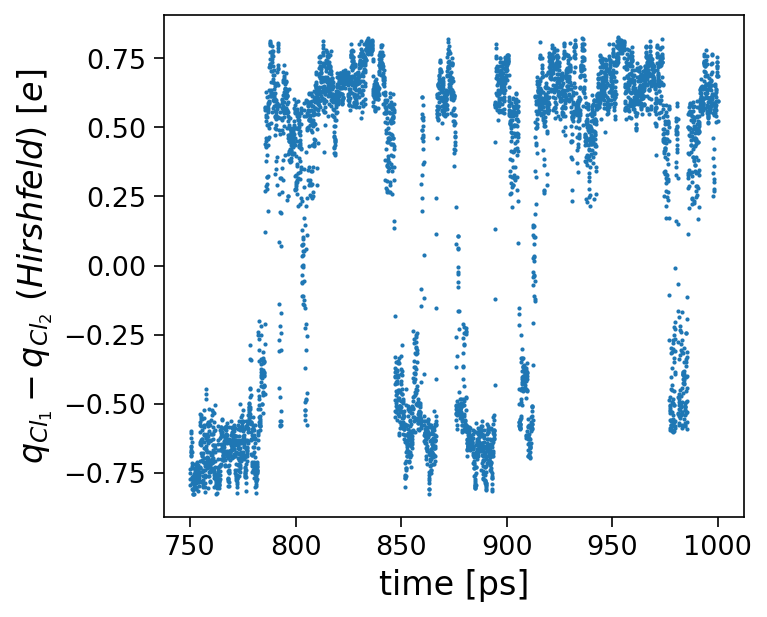

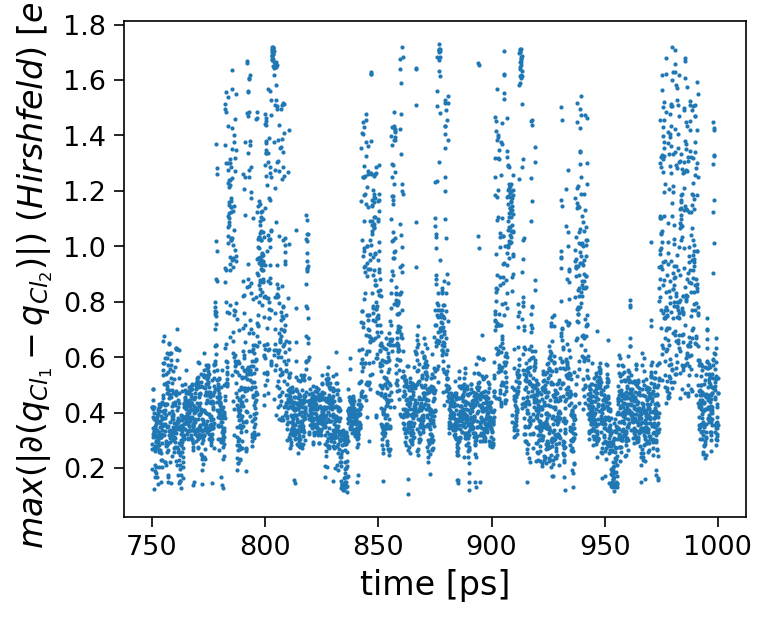

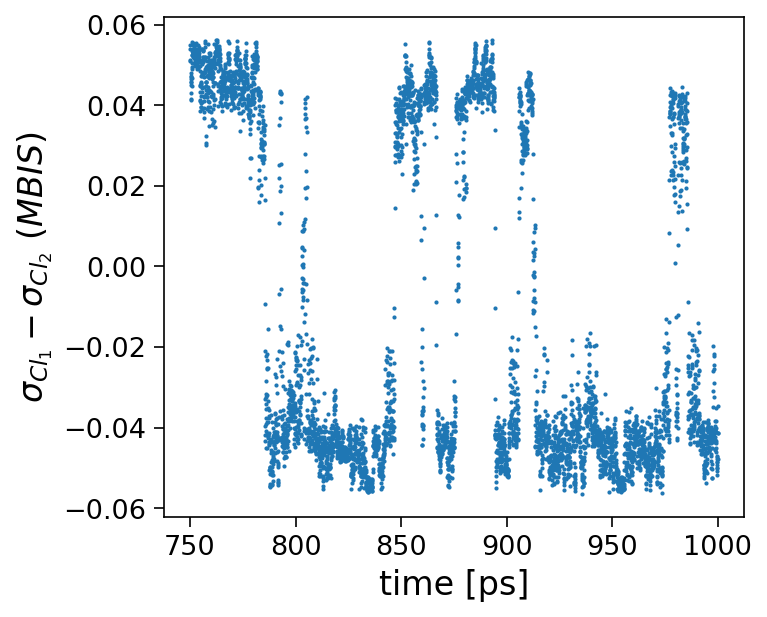

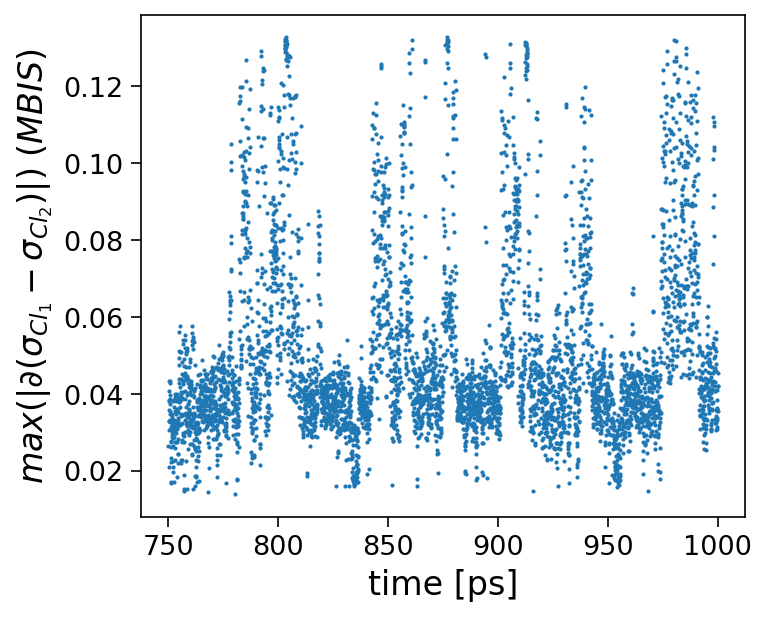

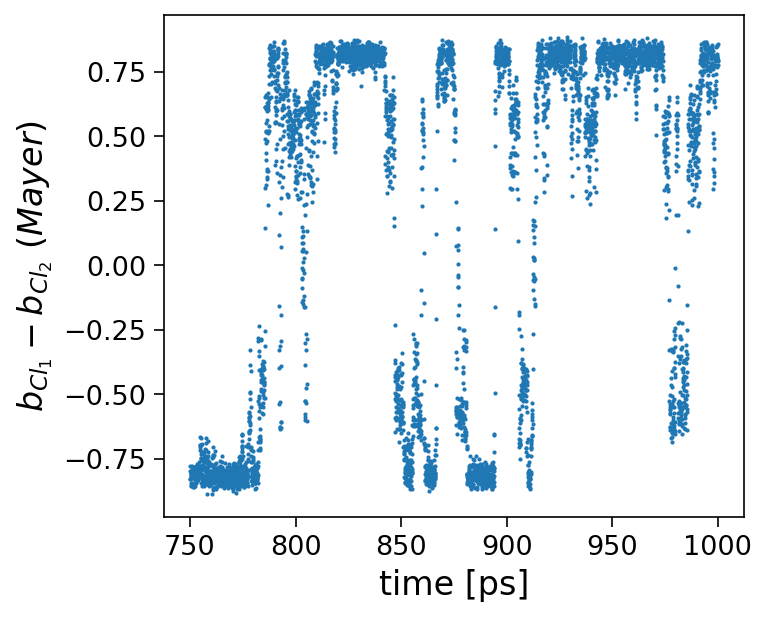

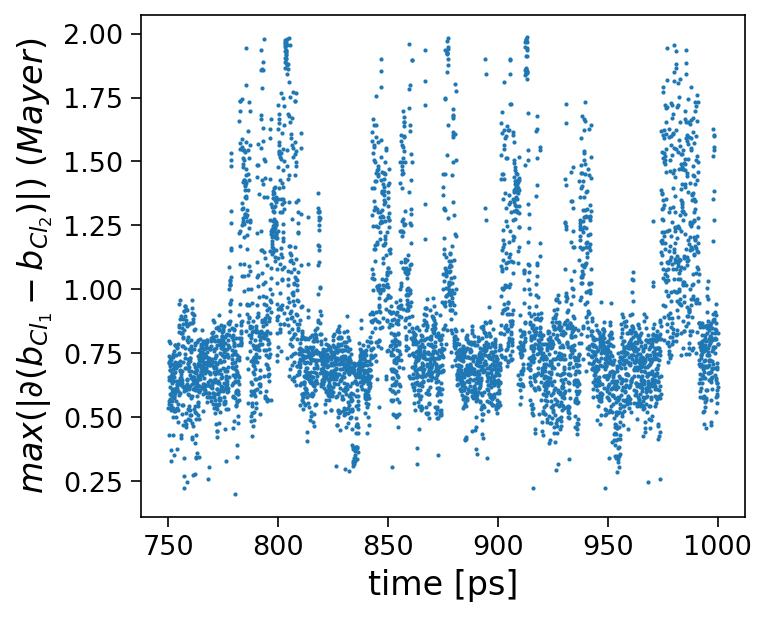

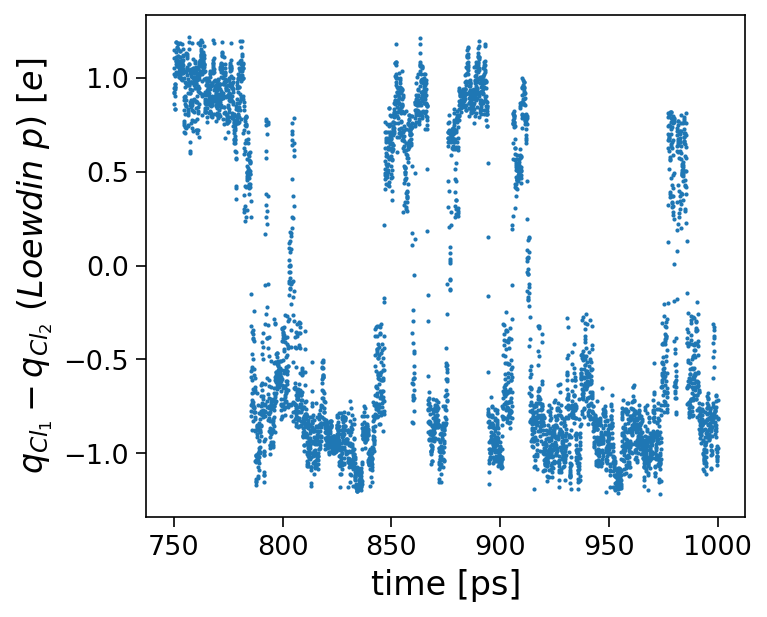

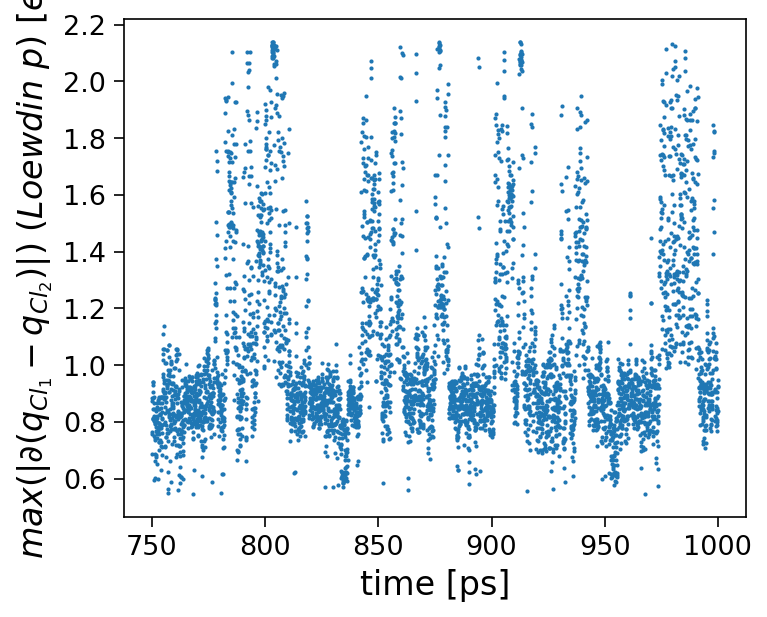

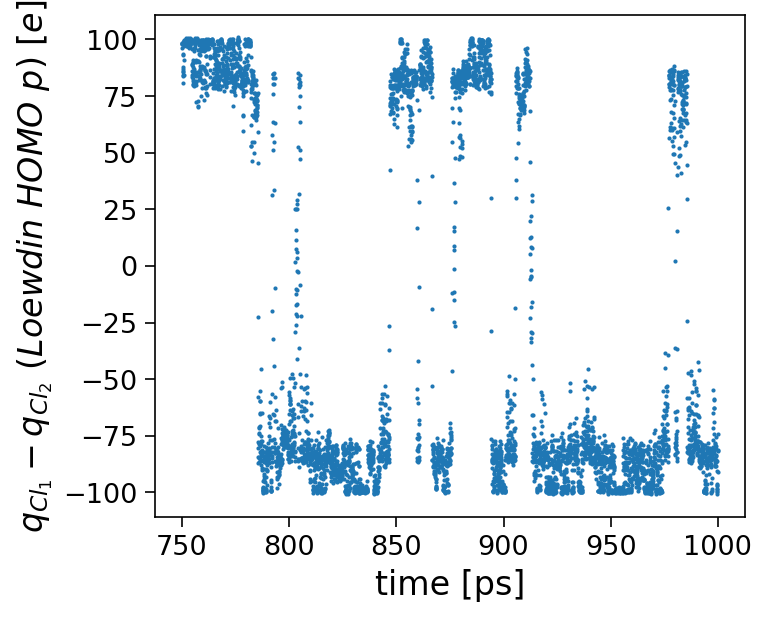

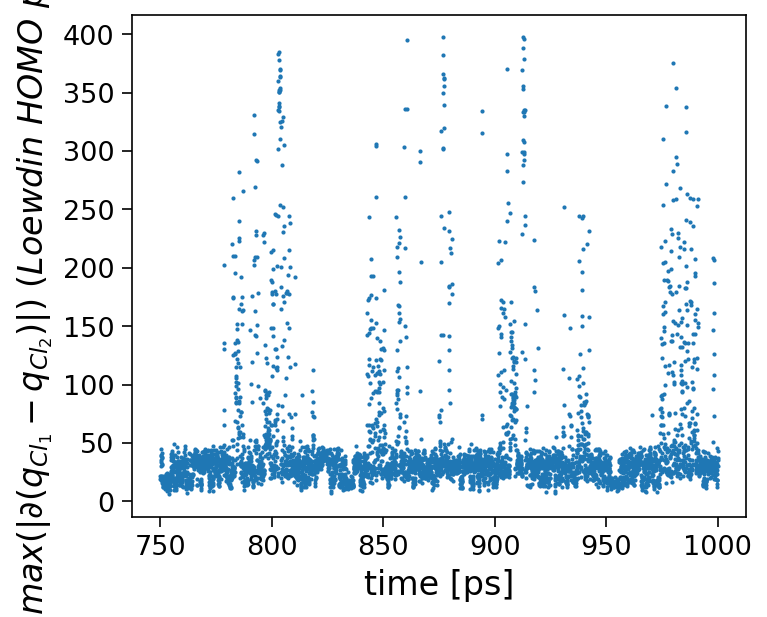

In [17]:
for key in labels:
    data_value = plumed.read_as_pandas(f"TEST_TRAJ/{key}/CHEMCV_value")
    chemcv_value = data_value["chemcv.node-0"].to_numpy().T

    data_derivative = plumed.read_as_pandas(f"TEST_TRAJ/{key}/CHEMCV_derivative")
    chemcv_derivative = data_derivative["chemcv.node-0"].to_numpy().T
    chemcv_derivative = np.reshape(chemcv_derivative, (-1,9,3))[:,:6,:]

    fig = figures.trj(
        time=data["time"].to_numpy(),
        cv=chemcv_value,
        label=labels[key],
    )
    fig.savefig(f"TEST_TRAJ/{key}/trj_value.svg")

    fig = figures.trj(
        time=data["time"].to_numpy(),
        cv=[np.max([np.linalg.norm(atom) for atom in index]) for index in chemcv_derivative],
        label=labels_derivative[key],
    )
    fig.savefig(f"TEST_TRAJ/{key}/trj_max_norm_derivative.svg")